In [51]:
# Импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import accuracy_score
from scipy.stats import shapiro


RANDOM_STATE = 42

In [52]:
# Загрузка датасета
data = pd.read_csv('glass.csv')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [53]:
# Количество записей для каждого класса
class_counts = data['Type'].value_counts()
print("Количество записей для каждого класса:")
print(class_counts)

Количество записей для каждого класса:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


### Вывод о распределении классов
В наборе данных преобладают типы стекла `2` (76 записей) и `1` (70 записей). Типы `7`, `3`, `5` и `6` представлены значительно меньше. Это указывает на дисбаланс классов в датасете.

In [54]:
# Разбивка данных
X = data.drop('Type', axis=1)
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
#  Функция для обучения случайного леса и вывода метрики accuracy
def fit_model(X_train, X_test, y_train, y_test, model=RandomForestClassifier(random_state=RANDOM_STATE)):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_pred, y_test):.2f}')
    return model

In [56]:
# Случайный лес и accuracy для необработанныхх данных
fit_model(X_train, X_test, y_train, y_test)

Accuracy: 0.84


RandomForestClassifier(random_state=42)

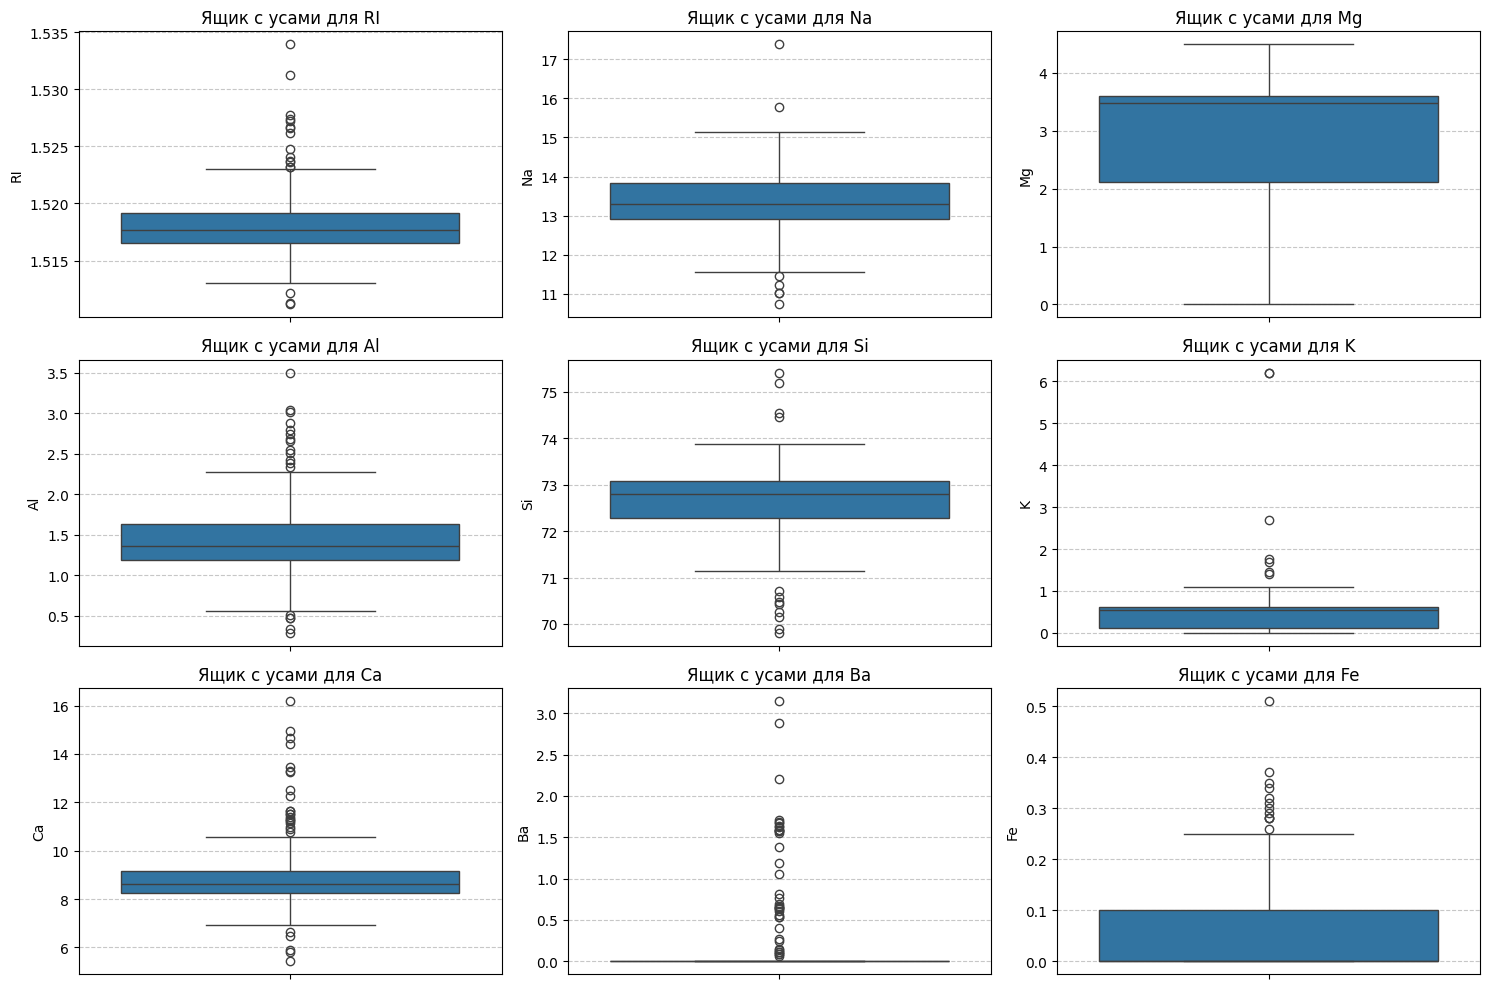

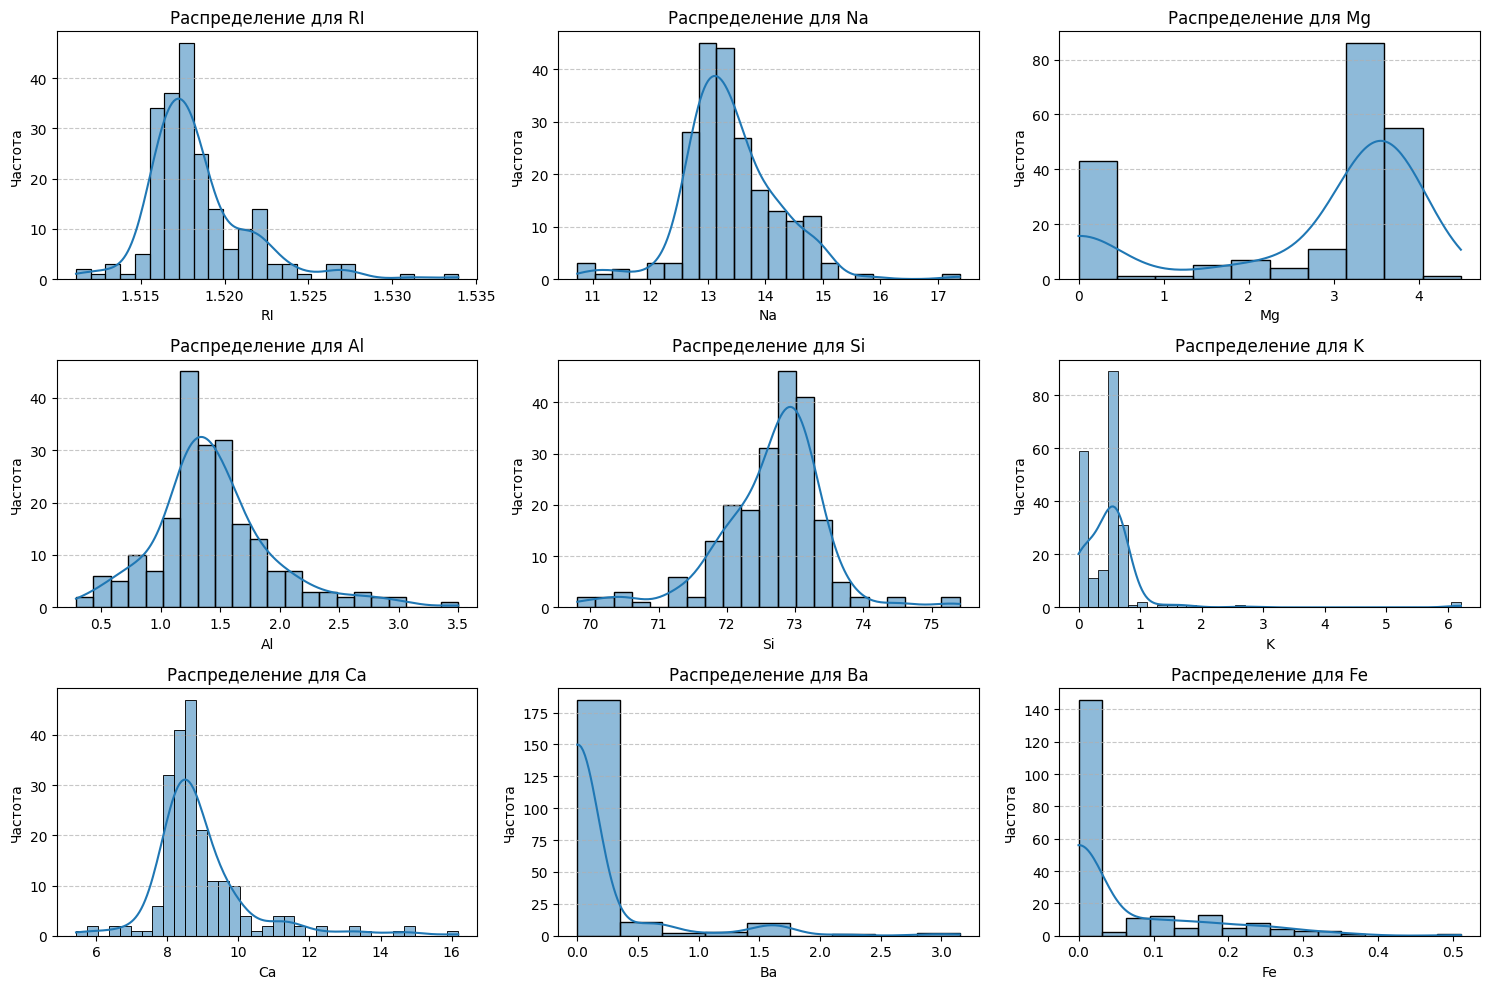

In [57]:
# Ящики с усами для всех признаков
plt.figure(figsize=(15, 10))
for i, column in enumerate(X.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=X[column])
    plt.title(f'Ящик с усами для {column}')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 10))
for i, column in enumerate(X.columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(X[column], kde=True)
    plt.title(f'Распределение для {column}')
    plt.ylabel('Частота')
    plt.xlabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [58]:

# Тест Шапиро-Уилка
print("Проверка признаков на нормальное распределение (тест Шапиро-Уилка):")
alpha = 0.05 # Уровень значимости
normal_features = []
for column in X_train.columns:
    stat, p = shapiro(X_train[column])
    print(f'  Признак {column}: Statistics={stat:.3f}, p={p:.3f}')
    if p > alpha:
        print(f'    -> Вероятно, нормально распределен (нельзя отклонить нулевую гипотезу)')
        normal_features.append(column)
    else:
        print(f'    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)')

print(f"\nПризнаки, которые, вероятно, нормально распределены (p > {alpha}): {normal_features if normal_features else 'Нет таких признаков'}")


Проверка признаков на нормальное распределение (тест Шапиро-Уилка):
  Признак RI: Statistics=0.851, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Na: Statistics=0.957, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Mg: Statistics=0.687, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Al: Statistics=0.938, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Si: Statistics=0.915, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак K: Statistics=0.486, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Ca: Statistics=0.782, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Ba: Statistics=0.389, p=0.000
    -> Вероятно, не нормально распределен (отклоняем нулевую гипотезу)
  Признак Fe: Statistics=0.666, p=0.000
    -

In [59]:
# Метод межквартильного размаха
print("Исследование признаков на выбросы (метод IQR):")
outlier_indices = set()

for column in X_train.columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Выбросы для текущего столбца
    col_outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)]
    print(f'  Признак {column}: обнаружено {len(col_outliers)} выбросов ({(len(col_outliers)/len(X_train))*100:.2f}%)')

    outlier_indices.update(col_outliers.index)

print(f"\nВсего уникальных строк с выбросами (по методу IQR): {len(outlier_indices)} из {len(X_train)} ({len(outlier_indices)/len(X_train)*100:.2f}%)")

Исследование признаков на выбросы (метод IQR):
  Признак RI: обнаружено 11 выбросов (6.43%)
  Признак Na: обнаружено 5 выбросов (2.92%)
  Признак Mg: обнаружено 29 выбросов (16.96%)
  Признак Al: обнаружено 17 выбросов (9.94%)
  Признак Si: обнаружено 10 выбросов (5.85%)
  Признак K: обнаружено 6 выбросов (3.51%)
  Признак Ca: обнаружено 19 выбросов (11.11%)
  Признак Ba: обнаружено 29 выбросов (16.96%)
  Признак Fe: обнаружено 11 выбросов (6.43%)

Всего уникальных строк с выбросами (по методу IQR): 62 из 171 (36.26%)


In [60]:
#  Иссдедование на выбросы с помощью IsolationForest
print("\n Исследование признаков на выбросы (метод Isolation Forest):")

iso_forest = IsolationForest(random_state=RANDOM_STATE, contamination=0.2)

outlier_predictions_iso = iso_forest.fit_predict(X_train)

# Получение индексов выбросов
outlier_indices_iso = X_train.index[outlier_predictions_iso == -1]
total_outliers_indices = set(outlier_indices).intersection(set(outlier_indices_iso))

print(f'  Количество выбросов, обнаруженных Isolation Forest: {len(outlier_indices_iso)} из {len(X_train)} ({(len(outlier_indices_iso)/len(X_train))*100:.2f}%)')
print(f"Общие выбросы между IQR и Isolation Forest: {len(total_outliers_indices)}")


 Исследование признаков на выбросы (метод Isolation Forest):
  Количество выбросов, обнаруженных Isolation Forest: 34 из 171 (19.88%)
Общие выбросы между IQR и Isolation Forest: 33


In [61]:
# Удаление выбросов

# Копии тренировочных данных для очистки
X_train_cleaned = X_train.copy()
y_train_cleaned = y_train.copy()

# Удаление выбросов из тренировочного множества
X_train_cleaned = X_train.drop(total_outliers_indices)
y_train_cleaned = y_train.drop(total_outliers_indices)

# Исходное количество записей для каждого класса
original_class_counts_train = y_train.value_counts().sort_index()
print(" \n Исходное количество записей для каждого класса в тренировочном наборе:")
print(original_class_counts_train)

# Количество записей для каждого класса после удаления выбросов
cleaned_class_counts_train = y_train_cleaned.value_counts().sort_index()
print("\n Количество записей для каждого класса в тренировочном наборе после удаления выбросов:")
print(cleaned_class_counts_train)



 
 Исходное количество записей для каждого класса в тренировочном наборе:
Type
1    59
2    62
3    14
5     9
6     6
7    21
Name: count, dtype: int64

 Количество записей для каждого класса в тренировочном наборе после удаления выбросов:
Type
1    58
2    53
3    13
5     5
6     5
7     4
Name: count, dtype: int64


In [62]:
#  Расчет процента удаленных записей по классам в тренировочном наборе
print("\n  Процент удаленных записей от общего числа записей для каждого класса в тренировочном наборе:")
removed_percentages_train = {}
for class_type in original_class_counts_train.index:
    original_count = original_class_counts_train.get(class_type, 0)
    cleaned_count = cleaned_class_counts_train.get(class_type, 0)
    if original_count > 0:
        removed_count = original_count - cleaned_count
        percentage = (removed_count / original_count) * 100
        removed_percentages_train[class_type] = percentage
        print(f'    Класс {class_type}: Удалено {removed_count} записей ({percentage:.2f}%)')
    else:
        removed_percentages_train[class_type] = 0.0
        print(f'    Класс {class_type}: Нет записей в исходном тренировочном наборе.')


  Процент удаленных записей от общего числа записей для каждого класса в тренировочном наборе:
    Класс 1: Удалено 1 записей (1.69%)
    Класс 2: Удалено 9 записей (14.52%)
    Класс 3: Удалено 1 записей (7.14%)
    Класс 5: Удалено 4 записей (44.44%)
    Класс 6: Удалено 1 записей (16.67%)
    Класс 7: Удалено 17 записей (80.95%)


In [63]:
# Случайный лес и accuracy без выбросов
model_cleaned = fit_model(X_train_cleaned, X_test, y_train_cleaned, y_test)

Accuracy: 0.79


### Вывод

**Преобразования данных:**

1.  **Загрузка и начальный осмотр:** Загружен набор данных `glass.csv`. Проверен тип данных и наличие пропущенных значений (`data.info()`, `data.head()`).
2.  **Анализ распределения классов:** Определено количество записей для каждого класса в целевой переменной `Type`. Выявлен дисбаланс классов (большинство записей относятся к классам 1 и 2).
3.  **Разбивка данных:** Данные были разделены на признаки (`X`) и целевую переменную (`y`). Затем эти данные были разбиты на обучающую (`X_train`, `y_train`) и тестовую (`X_test`, `y_test`) выборки с соотношением 80/20.
4.  **Визуализация признаков:** Для всех признаков построены ящики с усами (boxplot) и гистограммы (`sns.boxplot`, `sns.histplot`). Это позволило визуально оценить распределение данных и наличие выбросов.
5.  **Тест на нормальность:** Применен тест Шапиро-Уилка к признакам в обучающей выборке (`X_train`). Установлено, что **ни один из признаков не является нормально распределенным** (все p-значения значительно ниже уровня значимости 0.05).
6.  **Выявление выбросов (IQR):** Выбросы были обнаружены с использованием метода межквартильного размаха (IQR). Для каждого признака были рассчитаны Q1, Q3, IQR, а также нижняя и верхняя границы. Записи, выходящие за эти границы, были отмечены как выбросы. Это делалось **только на обучающей выборке** для предотвращения утечки данных.
7.  **Выявление выбросов (Isolation Forest):** В качестве второго метода для обнаружения выбросов был использован алгоритм Isolation Forest. Этот метод также применялся **только к обучающей выборке**.
8.  **Объединение выбросов и удаление:** Идентификаторы выбросов, обнаруженные обоими методами (IQR и Isolation Forest), были объединены. Затем эти записи были удалены из обучающей выборки (`X_train`, `y_train`), создав очищенные наборы `X_train_cleaned` и `y_train_cleaned`.
9.  **Анализ удаленных записей:** Рассчитан и выведен процент удаленных записей для каждого класса, что показало разную степень влияния на различные классы.

**Сравнение точности двух моделей:**

*   **Модель на исходных данных:** Точность (Accuracy) модели RandomForestClassifier на необработанных данных составила **0.84**.
*   **Модель на очищенных данных (без выбросов):** Точность (Accuracy) модели RandomForestClassifier на данных, из которых были удалены выбросы, составила **0.79**.

В данном случае **удаление выбросов привело к снижению точности модели** с 0.84 до 0.79. Это может быть связано с тем, что удаленные записи, хотя и были определены как выбросы, содержали важную информацию для классификации, или же алгоритм Isolation Forest определил как выбросы значимые для обучения данные. Также, уменьшение размера обучающей выборки могло негативно сказаться на способности модели к обобщению.

**Нужно ли исследовать данные на выбросы, для чего это делается, плюсы и минусы подхода:**

**Нужно ли исследовать данные на выбросы?**

Да, исследование данных на выбросы, безусловно, нужно и является важным этапом анализа данных и машинного обучения. Выбросы могут существенно влиять на результаты статистического анализа и производительность моделей.

**Для чего это делается?**

1.  **Улучшение качества модели:** Некоторые модели машинного обучения (например, линейные модели, SVM, нейронные сети) очень чувствительны к выбросам, которые могут смещать их параметры и приводить к некорректным предсказаниям. Удаление или обработка выбросов может повысить стабильность и точность таких моделей.
2.  **Корректность статистического анализа:** Выбросы могут искажать средние значения, стандартные отклонения, корреляции и другие статистические показатели, что приводит к неверным выводам.
3.  **Обнаружение ошибок данных:** Иногда выбросы являются не аномальными, а ошибочными записями (например, ошибки ввода данных или сбои датчиков), которые необходимо исправить или удалить.
4.  **Выявление важных аномалий:** В некоторых задачах сами выбросы могут быть наиболее интересными данными (например, обнаружение мошенничества, медицинская диагностика, аномалии в сетевом трафике).

**Плюсы подхода к обработке выбросов:**

*   **Повышение точности чувствительных моделей:** Для моделей, восприимчивых к выбросам, их удаление или трансформация может значительно улучшить производительность.
*   **Улучшение интерпретируемости:** Очищенные от выбросов данные могут давать более четкие статистические зависимости и распределения.
*   **Снижение шума:** Выбросы часто являются шумом, который мешает моделировать истинные закономерности в данных.

**Минусы подхода к обработке выбросов:**

*   **Потеря данных:** Удаление выбросов всегда ведет к потере некоторого объема данных, что может быть критично для небольших выборок или если выбросы содержат важную информацию.
*   **Потеря важной информации:** Выбросы могут быть не ошибкой, а редкими, но очень значимыми событиями или наблюдениями. Их удаление может привести к потере ценных паттернов.
*   **Неверное определение выбросов:** Методы обнаружения выбросов не всегда идеальны и могут ошибочно классифицировать нормальные точки как выбросы, или пропустить истинные выбросы.
*   **Сложность в выборе метода:** Не существует универсального метода обработки выбросов. Выбор зависит от типа данных, целей анализа и используемой модели.
*   **Влияние на распределение классов:** Как показал данный анализ, удаление выбросов может непропорционально затронуть различные классы, усугубляя проблему дисбаланса классов или создавая ее там, где не было.